# OCR hóa đơn & bill chuyển khoản — TRAIN FROM SCRATCH (Colab)

Notebook train **1 model nhận dạng dòng chữ CRNN+CTC từ đầu** (không pretrain, không finetune),
hoạt động trên ảnh hóa đơn POS **và** biên lai chuyển khoản ngân hàng/ví thật.

**Kiến trúc OCR mới (tất cả phần học máy đều train from scratch):**
1. Phát hiện dòng chữ bằng xử lý ảnh cổ điển (`app/ocr_detect.py`) — không cần train.
2. Recognizer CRNN+CTC tổng quát (`data/train_ocr_recognizer.py`) — học từ dữ liệu synthetic
   sinh on-the-fly (`data/gen_ocr_lines.py`): tên cửa hàng, dòng món + giá, TỔNG CỘNG, ngày giờ,
   và các trường bill chuyển khoản (Số tiền / Người nhận / Nội dung / Mã GD / Ngân hàng...).
3. Bóc tách field tái dùng logic regex sẵn có (`app/ocr_real.py`).

**Yêu cầu:** Runtime → Change runtime type → **T4 GPU**.

**Luồng:** CELL 0 → 1 → 2 → (3 xem mẫu) → **3.5 chuẩn bị dòng thật** → 4 train (resume) → 5 eval synthetic → 6 test ảnh upload → 6B eval ảnh thật → 7 backup.

**Colab 2h20 — train nhiều phiên (KHÔNG train một mạch):**
- CELL 4 tự **dừng + lưu checkpoint** sau ~130 phút và sau MỖI epoch.
- Khi hết giờ / bị ngắt: **chạy lại CELL 4** → tự **resume** từ epoch dang dở (checkpoint nằm trên Drive).
- Lặp lại tới khi log báo "Da train du epochs" hoặc early stop.

**Dùng dữ liệu thật của bạn (`data_train/`):** CELL 3.5 tách dòng + tạo `labels.csv` (có nhãn gợi ý để bạn sửa nhanh). Sửa xong, CELL 4 sẽ trộn 30% dòng thật vào mỗi batch.

**Nâng cấp so với bản trước (sửa lỗi nuốt ký tự / mất dấu ở dòng dài):**
- `width_divisor=8` → số bước CTC (T) gấp đôi (lên 128) → đủ "khe" căn ký tự dòng 40-60 ký tự.
- LSTM hidden 384, `max_w=1024`, dropout 0.25.
- Dataset thêm nhiều dòng dài 20-60 ký tự, từ khóa hóa đơn (THÀNH TIỀN/VAT/GIẢM GIÁ...), số hàng nghìn lớn, tiếng Việt có dấu.
- Augmentation thêm motion blur + JPEG compression.
- Hậu xử lý `app/ocr_postprocess.py` tự sửa từ khóa OCR sai (TgNG→TỔNG, VNB→VND...).


In [5]:
# ══════════════════════════════════════════════════════════════
# CELL 0 — Cài thư viện + Mount Google Drive
# ══════════════════════════════════════════════════════════════
import subprocess, sys
from pathlib import Path

def pip(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

for mod, pkg in [("torch", "torch"), ("numpy", "numpy"), ("pandas", "pandas"),
                 ("PIL", "Pillow"), ("matplotlib", "matplotlib")]:
    try:
        __import__(mod)
    except ImportError:
        pip(pkg)

# OpenCV (phát hiện dòng tốt hơn — có fallback numpy nếu thiếu)
try:
    import cv2  # noqa
except ImportError:
    pip("opencv-python-headless")

# Font đa dạng cho synthetic
subprocess.run(["apt-get", "install", "-y", "-qq",
                "fonts-dejavu", "fonts-liberation", "fonts-freefont-ttf", "fonts-noto-core"],
               check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

from google.colab import drive
drive.mount("/content/drive")
print("Drive mounted.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.


In [6]:
# ══════════════════════════════════════════════════════════════
# CELL 1 — Tìm thư mục ai_service trên Drive + cấu hình đường dẫn
# ══════════════════════════════════════════════════════════════
from pathlib import Path
import sys

AI_ROOT = None
CANDIDATES = [
    Path("/content/drive/MyDrive/thesis/ocr_train"),
    Path("/content/drive/MyDrive/ocr_train"),
    Path("/content/drive/MyDrive/Doantotnghiep2/ocr_train"),
    Path("/content/ocr_train"),
]
for p in CANDIDATES:
    if (p / "app" / "ocr_net.py").is_file():
        AI_ROOT = p
        break
if AI_ROOT is None:
    for cand in Path("/content/drive/MyDrive").rglob("ocr_net.py"):
        if cand.parent.name == "app":
            AI_ROOT = cand.parent.parent
            break
assert AI_ROOT is not None, "Khong tim thay ai_service tren Drive (can co app/ocr_net.py)"

WORK_ROOT  = AI_ROOT
# Lưu THẲNG vào Drive để checkpoint + model KHÔNG MẤT khi Colab ngắt (2h20),
# nhờ vậy chạy lại là RESUME tiếp tục được.
MODELS_DIR   = AI_ROOT / "models"
DRIVE_MODELS = MODELS_DIR
LOG_DIR      = MODELS_DIR / "ocr_logs"
DATA_TRAIN   = AI_ROOT / "data_train"          # ảnh thật bạn tự thu thập (theo merchant)
REAL_DIR     = AI_ROOT / "data" / "real_lines" # dòng thật đã tách + nhãn (tạo ở CELL 3.5)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

if str(WORK_ROOT) not in sys.path:
    sys.path.insert(0, str(WORK_ROOT))

print("AI_ROOT      :", AI_ROOT)
print("MODELS_DIR   :", MODELS_DIR, "(model + checkpoint luu o Drive)")
print("DATA_TRAIN   :", DATA_TRAIN, "->", "CO" if DATA_TRAIN.is_dir() else "KHONG CO")
print("REAL_DIR     :", REAL_DIR)


AI_ROOT      : /content/drive/MyDrive/thesis/ocr_train
MODELS_DIR   : /content/drive/MyDrive/thesis/ocr_train/models (model + checkpoint luu o Drive)
DATA_TRAIN   : /content/drive/MyDrive/thesis/ocr_train/data_train -> CO
REAL_DIR     : /content/drive/MyDrive/thesis/ocr_train/data/real_lines


In [7]:
# ══════════════════════════════════════════════════════════════
# CELL 2 — GPU + siêu tham số
# ══════════════════════════════════════════════════════════════
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cpu":
    print("CANH BAO: dang dung CPU -> Runtime > Change runtime type > T4 GPU")

EPOCHS      = 28      # early-stop thường dừng sớm hơn
TRAIN_SIZE  = 50000   # số dòng synthetic mỗi epoch (on-the-fly)
VAL_SIZE    = 3000
BATCH_SIZE  = 48      # model lớn hơn (LSTM 384, T=128) → 48 an toàn T4 16GB; OOM thì giảm 32
PATIENCE    = 7
NUM_WORKERS = 4       # render on-the-fly là bottleneck CPU → tăng worker cho nhanh

# ── FINETUNE GHI CHÚ (đọc đúng 'mung me 8/3'...) ─────────────────
# Train TIẾP từ checkpoint hiện có, tập trung dòng ghi chú ngắn kiểu thật.
# Cách dùng: đặt FINETUNE_NOTES=True (EPOCHS sẽ tự +8 để train tiếp/resume).
FINETUNE_NOTES = False   # True khi muốn train tiếp cho ghi chú
NOTE_FOCUS     = 0.35    # 35% dòng train là ghi chú ngắn (chỉ khi FINETUNE_NOTES)
if FINETUNE_NOTES and EPOCHS <= 28:
    EPOCHS = 36          # +8 epoch train tiep (resume tu epoch 29)
print(f"EPOCHS={EPOCHS} TRAIN_SIZE={TRAIN_SIZE} BATCH={BATCH_SIZE} "
      f"FINETUNE_NOTES={FINETUNE_NOTES} NOTE_FOCUS={NOTE_FOCUS if FINETUNE_NOTES else 0}")
print("Nang cap: width_divisor=8 (T gap doi -> het nuot ky tu dong dai), "
      "LSTM 384, max_w=1024, dataset dong dai + postprocess sua loi tu khoa.")


Device: cuda
EPOCHS=28 TRAIN_SIZE=50000 BATCH=48 FINETUNE_NOTES=False NOTE_FOCUS=0
Nang cap: width_divisor=8 (T gap doi -> het nuot ky tu dong dai), LSTM 384, max_w=1024, dataset dong dai + postprocess sua loi tu khoa.


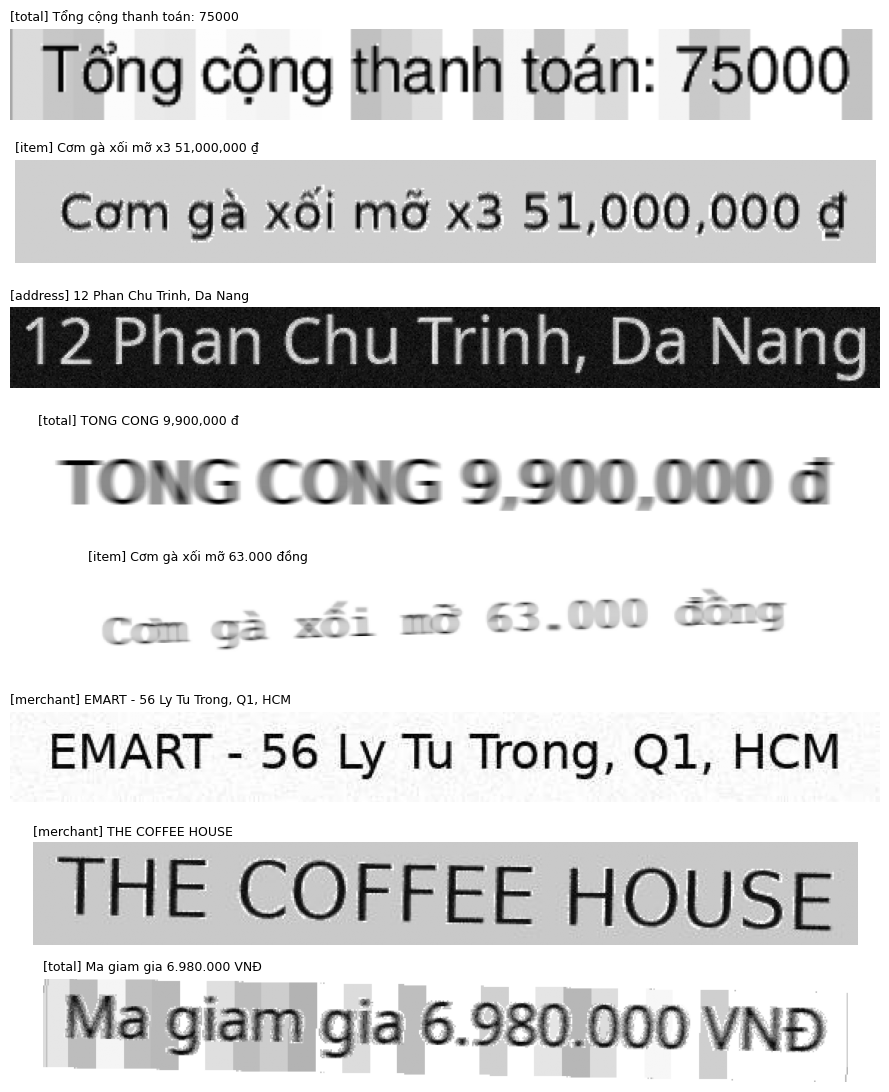

In [8]:
# ══════════════════════════════════════════════════════════════
# CELL 3 — (Tùy chọn) Xem thử vài dòng synthetic
# ══════════════════════════════════════════════════════════════
import random, sys
if str(WORK_ROOT / "data") not in sys.path:
    sys.path.insert(0, str(WORK_ROOT / "data"))
import matplotlib.pyplot as plt
from gen_ocr_lines import sample_line, render_line

rng = random.Random(7)
fig, axes = plt.subplots(8, 1, figsize=(9, 11))
for ax in axes:
    text, kind = sample_line(rng)
    img = render_line(text, rng, kind=kind, augment=True)
    ax.imshow(img, cmap="gray"); ax.axis("off")
    ax.set_title(f"[{kind}] {text}", fontsize=9, loc="left")
plt.tight_layout(); plt.show()


In [9]:
# ══════════════════════════════════════════════════════════════
# CELL 3.5 — CHUẨN BỊ DÒNG THẬT từ data_train/ (tách dòng + nhãn gợi ý)
# Chạy 1 LẦN. Sau đó MỞ REAL_DIR/labels.csv, sửa cột `text` cho đúng,
# xóa dòng rác (logo/vạch/nhiễu). Chỉ dòng có `text` mới được train.
# (Lần đầu chưa có model -> bỏ --pseudo, cột text trống, bạn tự gõ.)
# ══════════════════════════════════════════════════════════════
%cd {WORK_ROOT}
USE_PSEUDO = (MODELS_DIR / "ocr_reco_model.pt").is_file()  # có model thì điền nhãn gợi ý
pseudo_flag = "--pseudo" if USE_PSEUDO else ""
if DATA_TRAIN.is_dir():
    !python data/prepare_real_lines.py --src {DATA_TRAIN} --out {REAL_DIR} --models-dir {MODELS_DIR} {pseudo_flag}
    import pandas as pd
    csv = REAL_DIR / "labels.csv"
    if csv.is_file():
        df = pd.read_csv(csv).fillna("")
        print(f"\n{len(df)} dong | da co text: {(df['text'].astype(str).str.strip()!='').sum()}")
        display(df.head(20))
        print("\n>>> MO file nay tren Drive de sua nhan roi luu lai:", csv)
else:
    print("Khong thay data_train/ — bo qua. Train se chi dung synthetic.")

/content/drive/MyDrive/thesis/ocr_train

OK  45 anh -> 790 dong -> /content/drive/MyDrive/thesis/ocr_train/data/real_lines/images
    labels.csv -> /content/drive/MyDrive/thesis/ocr_train/data/real_lines/labels.csv
    pseudo-label: 666/790 dong conf>=0.80 (nen tin), con lai HAY SUA tay

BUOC TIEP: mo labels.csv, sua cot `text` cho dung, xoa dong rac. Chi dong co text se duoc dung khi train (--real-dir).

790 dong | da co text: 684


,image_path,text,conf,merchant,source
0,images/Bach_Hoa_Xanh__2902f4c5-8dc1-41d4-93fd-...,BÁCH HÓA XANH,0.9658,Bách Hóa Xanh,2902f4c5-8dc1-41d4-93fd-ee1bdef38232.jpg
1,images/Bach_Hoa_Xanh__2902f4c5-8dc1-41d4-93fd-...,WIMM: bachoaXanh con,0.9432,Bách Hóa Xanh,2902f4c5-8dc1-41d4-93fd-ee1bdef38232.jpg
2,images/Bach_Hoa_Xanh__2902f4c5-8dc1-41d4-93fd-...,KEYTAn I2N 0E2N: i h,0.7868,Bách Hóa Xanh,2902f4c5-8dc1-41d4-93fd-ee1bdef38232.jpg
3,images/Bach_Hoa_Xanh__2902f4c5-8dc1-41d4-93fd-...,ST: 21061069890098672,0.9781,Bách Hóa Xanh,2902f4c5-8dc1-41d4-93fd-ee1bdef38232.jpg
4,images/Bach_Hoa_Xanh__2902f4c5-8dc1-41d4-93fd-...,Ngày GT: 11/06/2021 19:48,0.9844,Bách Hóa Xanh,2902f4c5-8dc1-41d4-93fd-ee1bdef38232.jpg
5,images/Bach_Hoa_Xanh__2902f4c5-8dc1-41d4-93fd-...,Nhân vien: Hê Thuy Ngoc Trấn,0.9747,Bách Hóa Xanh,2902f4c5-8dc1-41d4-93fd-ee1bdef38232.jpg
6,images/Bach_Hoa_Xanh__2902f4c5-8dc1-41d4-93fd-...,SL Cê bấn TTiận,0.9593,Bách Hóa Xanh,2902f4c5-8dc1-41d4-93fd-ee1bdef38232.jpg
7,images/Bach_Hoa_Xanh__2902f4c5-8dc1-41d4-93fd-...,CA NGAN LAM SACH,0.9631,Bách Hóa Xanh,2902f4c5-8dc1-41d4-93fd-ee1bdef38232.jpg
8,images/Bach_Hoa_Xanh__2902f4c5-8dc1-41d4-93fd-...,"0.376 +0,500 59,250 22:278",0.9724,Bách Hóa Xanh,2902f4c5-8dc1-41d4-93fd-ee1bdef38232.jpg
9,images/Bach_Hoa_Xanh__2902f4c5-8dc1-41d4-93fd-...,"Tổng tiền22,278",0.9454,Bách Hóa Xanh,2902f4c5-8dc1-41d4-93fd-ee1bdef38232.jpg



>>> MO file nay tren Drive de sua nhan roi luu lai: /content/drive/MyDrive/thesis/ocr_train/data/real_lines/labels.csv


In [10]:
# ══════════════════════════════════════════════════════════════
# CELL 4 — TRAIN có CHECKPOINT/RESUME (Colab 2h20)
# ▶ Tự dừng + lưu checkpoint sau ~130 phút (--max-minutes 130).
# ▶ Bị ngắt / hết giờ: CHẠY LẠI ĐÚNG CELL NÀY -> tự RESUME từ epoch dang dở.
# ▶ Trộn dòng thật (REAL_DIR) vào synthetic nếu labels.csv đã có `text`.
# ▶ Lặp lại cho tới khi log in "Da train du epochs" hoặc early stop.
# ══════════════════════════════════════════════════════════════
%cd {WORK_ROOT}
REAL_RATIO  = 0.3    # 30% mẫu mỗi batch lấy từ dòng thật (nếu có nhãn)
MAX_MINUTES = 130    # < 140 phút (2h20) để kịp lưu checkpoint truoc khi Colab cat

real_arg = f"--real-dir {REAL_DIR}" if (REAL_DIR / 'labels.csv').is_file() else ""
note_arg = f"--note-focus {NOTE_FOCUS}" if FINETUNE_NOTES else ""
!python data/train_ocr_recognizer.py \
    --epochs {EPOCHS} --train-size {TRAIN_SIZE} --val-size {VAL_SIZE} \
    --batch-size {BATCH_SIZE} --patience {PATIENCE} --num-workers {NUM_WORKERS} \
    --models-dir {MODELS_DIR} --log-dir {LOG_DIR} --ckpt-dir {MODELS_DIR} \
    --max-minutes {MAX_MINUTES} --real-ratio {REAL_RATIO} {real_arg} {note_arg}

import json
meta_p = MODELS_DIR / "ocr_reco_meta.json"
ckpt_p = MODELS_DIR / "ocr_reco_ckpt.pt"
if meta_p.is_file():
    m = json.loads(meta_p.read_text(encoding="utf-8"))
    print(f"\nMODEL hien tai: best_val_cer={m.get('best_val_cer')} "
          f"val_exact={m.get('val_exact_acc')} epochs_run={m.get('epochs_run')} "
          f"params={m.get('params_million')}M")
print("Checkpoint:", "CO (resume duoc)" if ckpt_p.is_file() else "chua co")
print(">>> Neu log bao het gio/chua du epoch: CHAY LAI CELL NAY de train tiep.")


/content/drive/MyDrive/thesis/ocr_train
MODELS_DIR = /content/drive/MyDrive/thesis/ocr_train/models
LOG_DIR    = /content/drive/MyDrive/thesis/ocr_train/models/ocr_logs
CKPT_DIR   = /content/drive/MyDrive/thesis/ocr_train/models
REAL_DIR   = /content/drive/MyDrive/thesis/ocr_train/data/real_lines  (ratio=0.3)
MAX_MINUTES= 130.0 (se dung + luu checkpoint khi vuot)
Device: cuda  |  num_classes=214  charset=213
Real lines: 684 dong co nhan -> tron 30% vao train
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Model params: 12.96M
== RESUME tu checkpoint: epoch 29/28,

VAL  exact=0.9925  CER=0.0005  WER=0.0023  conf=0.9750


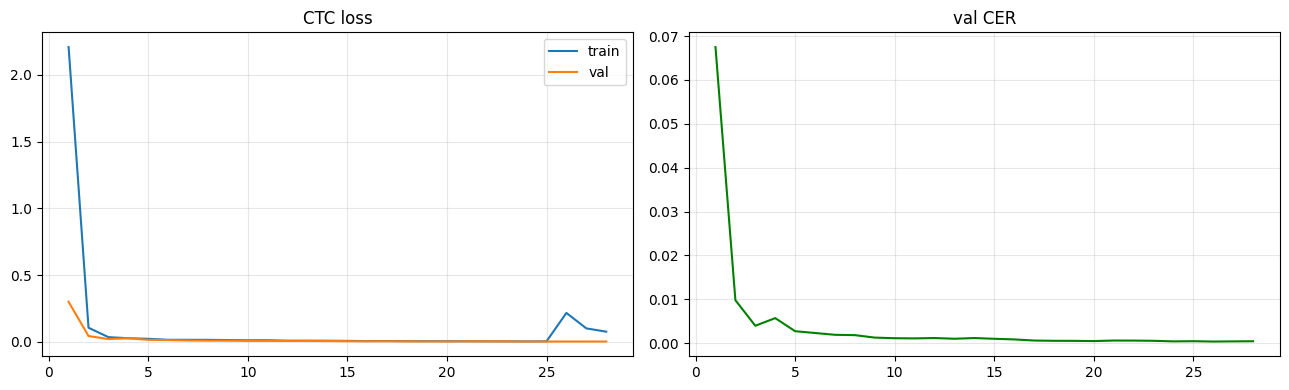

,reference,prediction,cer,exact,confidence
0,TỔNG SỐ TIỀN 849.000.000,TỔNG SỐ TIỀN 849.000.000,0.0,True,0.9904
1,"Khuyến mãi: 3,300,000 đồng","Khuyến mãi: 3,300,000 đồng",0.0,True,0.9587
2,Lời nhắn: tra no Mã hóa đơn,Lời nhắn: tra no Mã hóa đơn,0.0,True,0.9670
3,Ngay: 28.01.2024 10:31,Ngay: 28.01.2024 10:31,0.0,True,0.9750
4,Com tam suon bi cha x2 950.000 đ,Com tam suon bi cha x2 950.000 đ,0.0,True,0.9673
5,Giá trị giao dịch 656.000.000₫,Giá trị giao dịch 656.000.000₫,0.0,True,0.9773
6,Toi: Trần Thị Bích,Toi: Trần Thị Bích,0.0,True,0.9958
7,"12 Phan Chu Trinh, Da Nang","12 Phan Chu Trinh, Da Nang",0.0,True,0.9750
8,"Gia tri GD 2,890,000,000","Gia tri GD 2,890,000,000",0.0,True,0.9763
9,Bánh mì pa tê x 4 556.000.000 đ,Bánh mì pa tê x 4 556.000.000 đ,0.0,True,0.9812


In [11]:
# ══════════════════════════════════════════════════════════════
# CELL 5 — Đánh giá: metric + loss curve + bảng dự đoán (synthetic val)
# ══════════════════════════════════════════════════════════════
import pandas as pd, torch
from IPython.display import display
import matplotlib.pyplot as plt
import sys
if str(WORK_ROOT) not in sys.path:
    sys.path.insert(0, str(WORK_ROOT))

from app.ocr_recognizer import load_recognizer_bundle
import importlib, data.train_ocr_recognizer as T
importlib.reload(T)

bundle = load_recognizer_bundle(MODELS_DIR, device=DEVICE) or load_recognizer_bundle(DRIVE_MODELS, device=DEVICE)
assert bundle is not None, "Chua co model — chay CELL 4"

va_loader = torch.utils.data.DataLoader(
    T.SyntheticLineDataset(2000, augment=True, fixed=True),
    batch_size=64, shuffle=False, collate_fn=T.collate, num_workers=2,
)
metrics, preds, _ = T.evaluate(bundle.model, va_loader, DEVICE)
print("VAL  exact=%.4f  CER=%.4f  WER=%.4f  conf=%.4f"
      % (metrics["exact_acc"], metrics["mean_cer"], metrics["mean_wer"], metrics["mean_confidence"]))

log = LOG_DIR / "reco_epoch_log.csv"
if log.is_file():
    df = pd.read_csv(log)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(df["epoch"], df["train_loss"], label="train"); ax[0].plot(df["epoch"], df["val_loss"], label="val")
    ax[0].set_title("CTC loss"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(df["epoch"], df["val_cer"], color="green"); ax[1].set_title("val CER"); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

display(pd.DataFrame(preds).head(30))
